In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Problem Statement:
Leveraging the customer data collected by Aerofit consisting of the Gender, Age, Income, Weekly Usage, Fitness, Marital Status and Miles run on treadmill to identify characteristics which make the customer buy a particular treadmill out of KP281, KP481 and KP781 in the increasing order of expenditures. Further providing recommendations of treadmill for future orders/customers based on their profile.

In [4]:
df = pd.read_csv('D:\\learning\\ScalerDSML\\assets\\aerofit_data.csv')
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
print(f'shape of the dataset: {df.shape}')

shape of the dataset: (180, 9)


In [15]:
print(f'info in the dataset:')
df.info()

info in the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [16]:
print(f'Descriptive the dataset:')
df.describe()

Descriptive the dataset:


,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [23]:
num_cols=df.select_dtypes(include=["number"]).columns.to_list()
print(f'Numerical columns: {num_cols}')

Numerical columns: ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']


In [25]:
cat_cols=df.select_dtypes(include=["object"]).columns.to_list()
print(f'Categorical columns: {cat_cols}')

Categorical columns: ['Product', 'Gender', 'MaritalStatus']


In [32]:
for cat in cat_cols:
    print(f'\n***** Value counts for column: {cat} *****')
    print(df[cat].value_counts())
    print('#####'*10)


***** Value counts for column: Product *****
Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64
##################################################

***** Value counts for column: Gender *****
Gender
Male      104
Female     76
Name: count, dtype: int64
##################################################

***** Value counts for column: MaritalStatus *****
MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64
##################################################


In [34]:
df['Education'].value_counts()

Education
16    85
14    55
18    23
15     5
13     5
12     3
21     3
20     1
Name: count, dtype: int64

In [38]:
df['Fitness'].value_counts()

Fitness
3    97
5    31
2    26
4    24
1     2
Name: count, dtype: int64

In [44]:
# convert the categorical columns to numerical dtype
df_copy = df.copy()

df_copy['Gender'].replace(['Male','Female'],[1,0],inplace=True)
df_copy['MaritalStatus'].replace(['Single','Partnered'],[0,1],inplace=True)
df_copy['Product'].replace(['KP281','KP481','KP781'],[0,1,2],inplace=True)
df_copy.corr()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
Product,1.000000,0.032225,0.230653,0.495018,-0.017602,0.537447,0.594883,0.624168,0.571596
Age,0.032225,1.000000,0.027544,0.280496,0.192152,0.015064,0.061105,0.513414,0.036618
Gender,0.230653,0.027544,1.000000,0.094089,-0.018836,0.214424,0.254609,0.202053,0.217869
Education,0.495018,0.280496,0.094089,1.000000,0.068569,0.395155,0.410581,0.625827,0.307284
MaritalStatus,-0.017602,0.192152,-0.018836,0.068569,1.000000,-0.007786,-0.050751,0.150293,0.025639
Usage,0.537447,0.015064,0.214424,0.395155,-0.007786,1.000000,0.668606,0.519537,0.759130
Fitness,0.594883,0.061105,0.254609,0.410581,-0.050751,0.668606,1.000000,0.535005,0.785702
Income,0.624168,0.513414,0.202053,0.625827,0.150293,0.519537,0.535005,1.000000,0.543473
Miles,0.571596,0.036618,0.217869,0.307284,0.025639,0.759130,0.785702,0.543473,1.000000


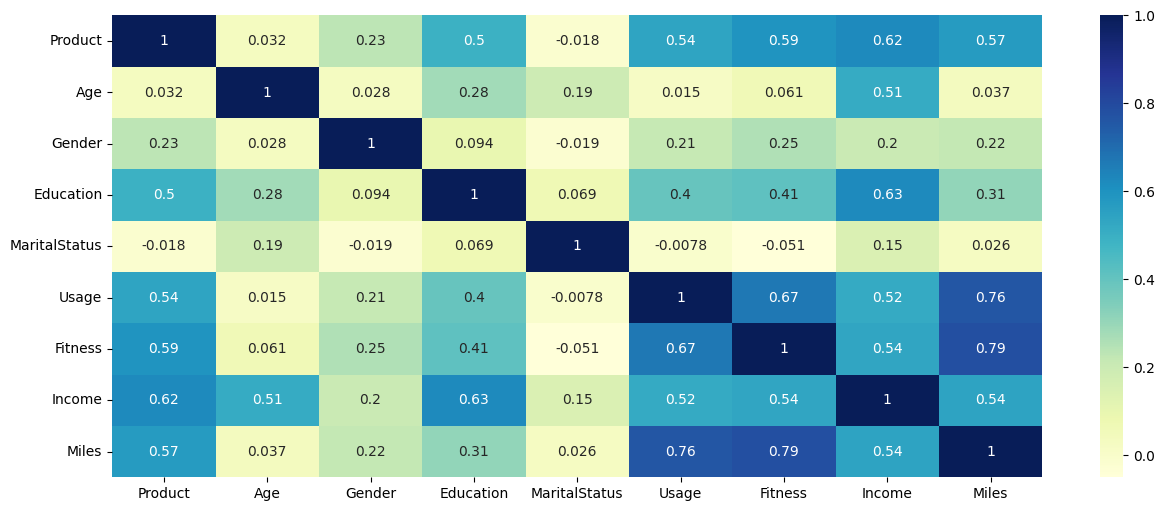

In [46]:
plt.figure(figsize=(15,6))
sns.heatmap(df_copy.corr(),cmap='YlGnBu',annot=True)
plt.show()

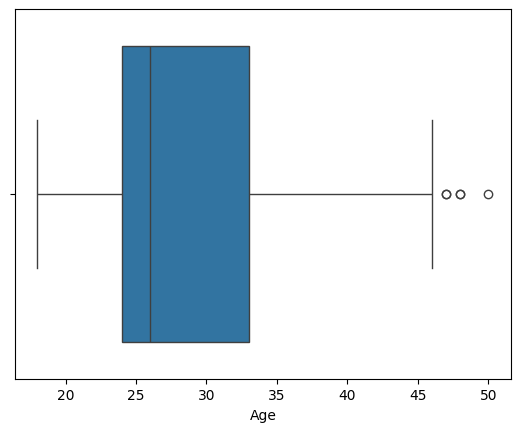

In [54]:
ax = sns.boxplot(x=df['Age'])
plt.show()

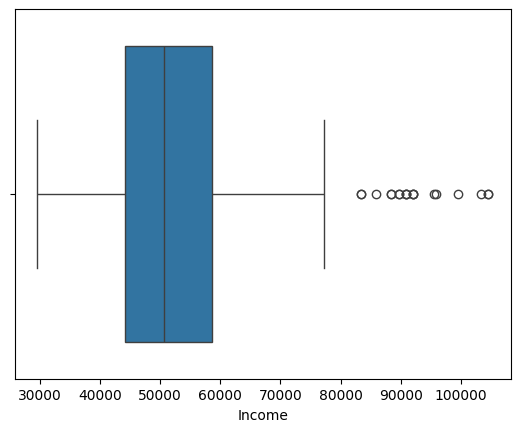

In [55]:
ax = sns.boxplot(x=df['Income'])

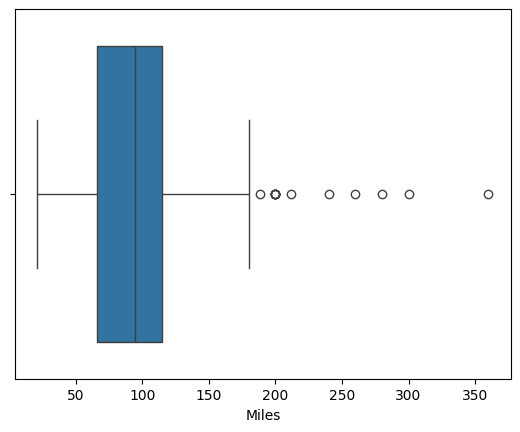

In [53]:
ax = sns.boxplot(x=df['Miles'])
plt.show()

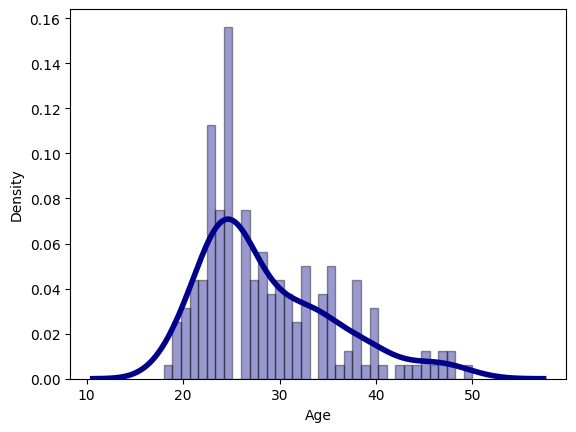

In [58]:
# removing outliers is not a good idea especially small data
# while analysing fraud detection removing outliers may lead to loss of important data points
sns.distplot(df['Age'],hist=True,kde=True,
             bins=36, color='darkblue',
             hist_kws={'edgecolor':'black'},
             kde_kws={'linewidth': 4})
plt.show()

In [61]:
bins = [-1,20,25,30,35,40,55]
labels = ['<20','20-25','25-30','30-35','35-40','40+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
df.head()
                        

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,AgeGroup
0,KP281,18,Male,14,Single,3,4,29562,112,<20
1,KP281,19,Male,15,Single,2,3,31836,75,<20
2,KP281,19,Female,14,Partnered,4,3,30699,66,<20
3,KP281,19,Male,12,Single,3,3,32973,85,<20
4,KP281,20,Male,13,Partnered,4,2,35247,47,<20


In [66]:
bins = [-1,50, 100,150, 400]
labels = ['<50','50-100','100-150','150+']
df['MilesGroup'] = pd.cut(df['Miles'], bins=bins, labels=labels)
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,AgeGroup,MilesGroup
0,KP281,18,Male,14,Single,3,4,29562,112,<20,100-150
1,KP281,19,Male,15,Single,2,3,31836,75,<20,50-100
2,KP281,19,Female,14,Partnered,4,3,30699,66,<20,50-100
3,KP281,19,Male,12,Single,3,3,32973,85,<20,50-100
4,KP281,20,Male,13,Partnered,4,2,35247,47,<20,<50


In [71]:
pd.crosstab(df['Gender'],df['Product'],normalize='index',margins=True)

Product,KP281,KP481,KP781
Gender,,,
Female,0.526316,0.381579,0.092105
Male,0.384615,0.298077,0.317308
All,0.444444,0.333333,0.222222


In [73]:
pd.crosstab(df['AgeGroup'],df['Product'],normalize='index',margins=True)

Product,KP281,KP481,KP781
AgeGroup,,,
<20,0.600000,0.400000,0.000000
20-25,0.405797,0.347826,0.246377
25-30,0.512195,0.170732,0.317073
30-35,0.343750,0.531250,0.125000
35-40,0.500000,0.375000,0.125000
40+,0.500000,0.166667,0.333333
All,0.444444,0.333333,0.222222


In [76]:
pd.crosstab(df['MilesGroup'],df['Product'],normalize='index',margins=True)

Product,KP281,KP481,KP781
MilesGroup,,,
<50,0.705882,0.294118,0.000000
50-100,0.515464,0.402062,0.082474
100-150,0.421053,0.342105,0.236842
150+,0.071429,0.107143,0.821429
All,0.444444,0.333333,0.222222


In [77]:
pd.crosstab(df['Education'],df['Product'],normalize='index',margins=True)

Product,KP281,KP481,KP781
Education,,,
12,0.666667,0.333333,0.000000
13,0.600000,0.400000,0.000000
14,0.545455,0.418182,0.036364
15,0.800000,0.200000,0.000000
16,0.458824,0.364706,0.176471
18,0.086957,0.086957,0.826087
20,0.000000,0.000000,1.000000
21,0.000000,0.000000,1.000000
All,0.444444,0.333333,0.222222
